In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

*************************************************************************
*                                                                       *
*                ███████████████████████████████████████                *
*                ▓  ▓▓▓▓  ▓▓  ▓▓▓▓  ▓▓        ▓▓       ▓                *
*                ▓   ▓▓   ▓▓  ▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓▓                *
*                ▒        ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒       ▒                *
*                ▒  ▒  ▒  ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒▒                *
*                ░  ░░░░  ░░░░    ░░░░░░░  ░░░░░       ░                *
*                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░                *
*                   https://github.com/wjwoodley/mute                   *
*                                                                       *
* Author:  William Woodley                                              *
* Version: 3.0.0                                                        *
*                                     

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '10' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Load Production Rates

In [4]:
Prop = Propagator(logE_mu_max=7.5)

C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(
C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(


In [5]:
df_Pfast = pd.read_csv('Production Rates/P_fast_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [6]:
for i,m in enumerate(model_names):
    print(i,m)

0 JN-fit_H-ice_alpha=0.63
1 GlobalSplineFitBeta_SIBYLL23CPP_alpha=0.63
2 HillasGaisser2012 H3a_SIBYLL23CPP_alpha=0.63
3 HillasGaisser2012 H4a_SIBYLL23CPP_alpha=0.63
4 GlobalSplineFitBeta_SIBYLL23C03_alpha=0.63
5 HillasGaisser2012 H3a_SIBYLL23C03_alpha=0.63
6 HillasGaisser2012 H4a_SIBYLL23C03_alpha=0.63
7 GlobalSplineFitBeta_SIBYLL-2.3c_alpha=0.63
8 HillasGaisser2012 H3a_SIBYLL-2.3c_alpha=0.63
9 HillasGaisser2012 H4a_SIBYLL-2.3c_alpha=0.63
10 GlobalSplineFitBeta_SIBYLL-2.3_alpha=0.63
11 HillasGaisser2012 H3a_SIBYLL-2.3_alpha=0.63
12 HillasGaisser2012 H4a_SIBYLL-2.3_alpha=0.63
13 GlobalSplineFitBeta_SIBYLL-2.1_alpha=0.63
14 HillasGaisser2012 H3a_SIBYLL-2.1_alpha=0.63
15 HillasGaisser2012 H4a_SIBYLL-2.1_alpha=0.63
16 GlobalSplineFitBeta_EPOS-LHC_alpha=0.63
17 HillasGaisser2012 H3a_EPOS-LHC_alpha=0.63
18 HillasGaisser2012 H4a_EPOS-LHC_alpha=0.63
19 GlobalSplineFitBeta_QGSJET-II-04_alpha=0.63
20 HillasGaisser2012 H3a_QGSJET-II-04_alpha=0.63
21 HillasGaisser2012 H4a_QGSJET-II-04_alpha=0.63
2

In [7]:
Prop.Phi['prod']=P_14C
C_flow = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:53<00:00, 135.19it/s]


## Statistics

In [8]:
f_2sigma = True # Use the 2-sigma hull values of the f-factors (False uses older chi^2 measurement)
Normalize = False # Normalize all production models to Heisinger?
error = 0.02 # relative systematic error of 14CO samples

In [9]:
if f_2sigma:
    df = pd.read_csv('factors_2sigma_hull.csv', header=None)
    f_factors = np.array([df[1],df[0]]).T
    f_weights = np.ones(len(f_factors))
else:
    df = pd.read_csv('14CO_f_all_ChiSq.csv')
    f_factors = np.array([df['fast'],df['f_neg']]).T[1:]
    f_weights = np.array(np.exp(-df['Chi_sq']/2))[1:] # convert chi^2 to prior weight

C_pred_0 = C_flow @ Prop.S_mat[Prop.i_start:]
# axis0 - Production Model
# axis1 - Production Mode (fast, neg)
# axis2 - Sample Depth

C_weights = np.ones(len(C_pred_0))

if Normalize:
    C_norm = np.sum(C_flow * Prop.dh[Prop.i_start:], axis=-1)
    
    C_pred_0 = C_pred_0 / np.reshape(C_norm, (-1,2,1)) * C_norm[-1].reshape(1,-1,1)

In [10]:
C_0 = np.average(C_pred_0, weights=C_weights, axis=0, keepdims=True)
# axis0 - Production Model
# axis1 - Production Mode (fast, neg)
# axis2 - Sample Depth

C_0_cov = np.moveaxis(np.reshape(
    np.cov(np.reshape(C_pred_0, (len(C_pred_0), -1)), rowvar=False, aweights=C_weights),
    (*np.shape(C_0), *np.shape(C_0)[1:])), (1,3), (-2,-1))
# axis0 - Production Model
# axis1 - Sample Depth A
# axis2 - Sample Depth B
# axis3 - Production Mode A
# axis4 - Production Mode B
    
C_w = np.ones(1)

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

f = np.average(f_factors, weights=f_weights, axis=0, keepdims=True)
# axis0 - f-factors
# axis1 - Production Mode

f_cov = np.reshape(np.cov(f_factors, rowvar=False, aweights=f_weights), (1,2,2))
# axis0 - f-factors
# axis1 - Production Mode A
# axis2 - Production Mode B

f_w = np.ones(1)

CO_0 = f @ C_0
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth

CO_0_cov = (np.reshape(f,(1,len(f),1,1,1,-1)) @ np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) @ np.reshape(f,(1,len(f),1,1,-1,1)))[:,:,:,:,0,0] + T(np.reshape(C_0, (len(C_0),1,2,-1))) @ np.reshape(f_cov, (1,len(f),2,2)) @ np.reshape(C_0, (len(C_0),1,2,-1)) + np.sum(np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) * np.reshape(f_cov, (1,len(f),1,1,2,2)), axis=(-2,-1))
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth A
# axis3 - Sample Depth B

rel_err = error * np.ones(np.shape(CO_0)[-1])
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

Sigma_0 = CO_0_cov * np.reshape(1+s_cov, (1,1,*np.shape(s_cov))) + np.reshape(CO_0, (*np.shape(CO_0),1)) * np.reshape(CO_0, (*np.shape(CO_0)[:-1],1,-1)) * np.reshape(s_cov, (1,1,*np.shape(s_cov)))
Sigma_0 = np.expand_dims(Sigma_0, axis=0)
# axis0 - NONE
# axis1 - Production Model
# axis2 - f-factors
# axis3 - Sample Depth A
# axis4 - Sample Depth B

Sigma_0_inv = np.linalg.inv(Sigma_0)

## Plots

In [40]:
CO_all_f = (f_factors @ C_pred_0)[:-1].reshape((7,-1,len(f_factors),10))[:,1:].reshape(7,11,3,len(f_factors),10).swapaxes(0,2)

In [11]:
CO_all = (f_avg @ C_pred_0)[:-1].reshape((7,-1,10))[:,1:].reshape(7,11,3,10).swapaxes(0,2)

In [12]:
m_names = np.array(model_names)[:-1].reshape((7,-1))[:,1:].reshape(7,11,3).swapaxes(0,2)

In [13]:
m_names[0,:,-1]

array(['GlobalSplineFitBeta_SIBYLL23CPP_alpha=0.75',
       'GlobalSplineFitBeta_SIBYLL23C03_alpha=0.75',
       'GlobalSplineFitBeta_SIBYLL-2.3c_alpha=0.75',
       'GlobalSplineFitBeta_SIBYLL-2.3_alpha=0.75',
       'GlobalSplineFitBeta_SIBYLL-2.1_alpha=0.75',
       'GlobalSplineFitBeta_EPOS-LHC_alpha=0.75',
       'GlobalSplineFitBeta_QGSJET-II-04_alpha=0.75',
       'GlobalSplineFitBeta_QGSJETII03_alpha=0.75',
       'GlobalSplineFitBeta_QGSJET01C_alpha=0.75',
       'GlobalSplineFitBeta_DPMJETIII306_alpha=0.75',
       'GlobalSplineFitBeta_DPMJETIII191_alpha=0.75'], dtype='<U45')

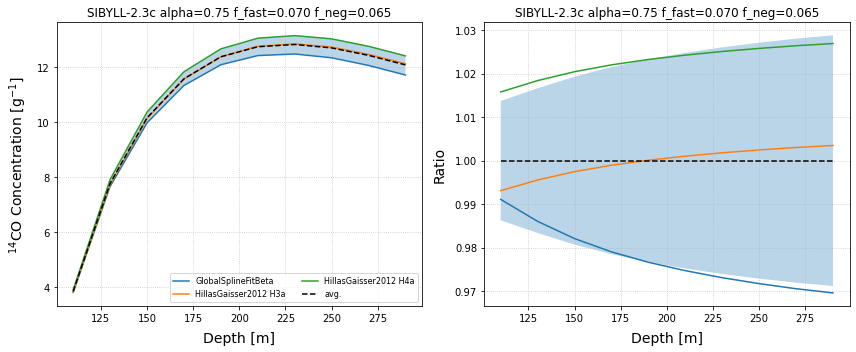

[0.01371429 0.01662735 0.0193014  0.02150361 0.02330484 0.02478222
 0.02604223 0.02711022 0.02804443 0.02881208]
Average relative uncertainty: 2.3%


In [27]:
# Uncertainty over Primary CR model

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all[:,2,-1]
names_cut = m_names[:,2,-1]
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c, label=names_cut[i].split('_')[0])
    ax1.plot(Prop.z_samp, c/CO_cut_avg, label=names_cut[i].split('_')[0])
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title='{1} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title='{1} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

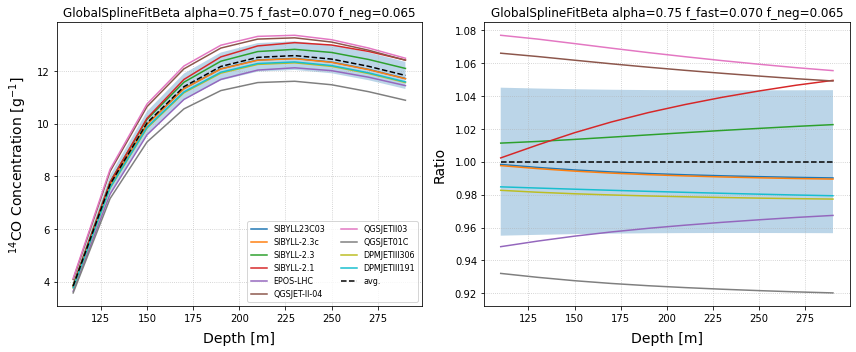

[0.04493421 0.04442217 0.04398934 0.04367962 0.04347928 0.04336411
 0.04331456 0.04331565 0.04335541 0.04341973]
Average relative uncertainty: 4.4%


In [28]:
# Uncertainty over Propagation model

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all[0,1:,-1]
names_cut = m_names[0,1:,-1]
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c, label=names_cut[i].split('_')[1])
    ax1.plot(Prop.z_samp, c/CO_cut_avg, label=names_cut[i].split('_')[1])
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title='{0} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title='{0} {2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

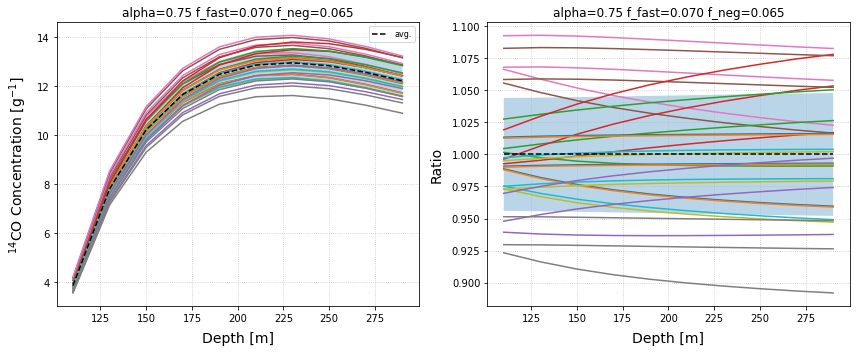

[0.04404371 0.04432855 0.04474486 0.04521564 0.04570336 0.04618214
 0.04665616 0.04711067 0.04755225 0.04794891]
Average relative uncertainty: 4.6%


In [45]:
# Uncertainty over Propagation model

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all[:,1:,-1].reshape((-1,np.shape(CO_all)[-1]))
#names_cut = m_names[:,1:,-1].reshape((-1))
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c)
    ax1.plot(Prop.z_samp, c/CO_cut_avg)
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title='{2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title='{2} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

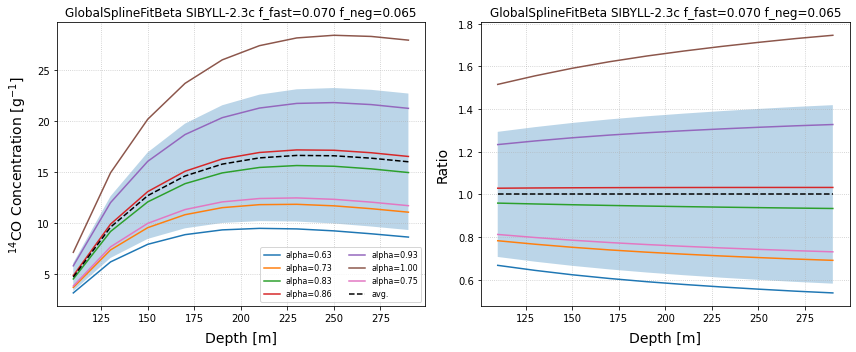

[0.29320754 0.31527408 0.33480195 0.35154712 0.36606304 0.37876025
 0.39024444 0.40055582 0.41008727 0.41833255]
Average relative uncertainty: 36.6%


In [29]:
# Uncertainty over 14C Production model

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all[0,2,:]
names_cut = m_names[0,2,:]
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c, label=names_cut[i].split('_')[2])
    ax1.plot(Prop.z_samp, c/CO_cut_avg, label=names_cut[i].split('_')[2])
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title='{0} {1} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title='{0} {1} f_fast={3:.3f} f_neg={4:.3f}'.format(*names_cut[0].split('_'), *f_avg)
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

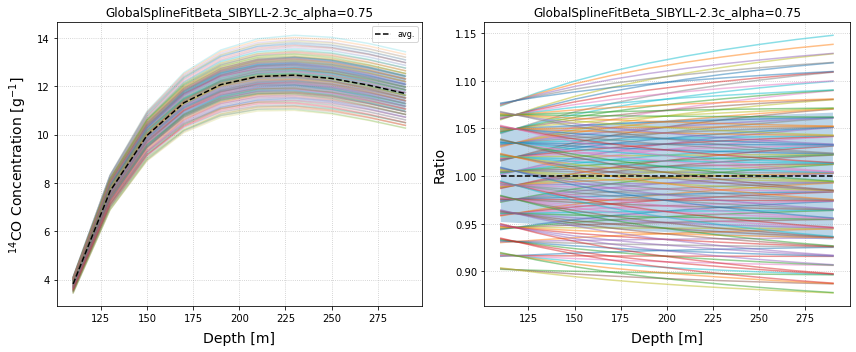

[0.04810896 0.05043752 0.05298456 0.05544598 0.05773552 0.05982285
 0.06176329 0.06353537 0.06519022 0.06662959]
Average relative uncertainty: 5.8%


In [47]:
# Uncertainty over f-factors

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all_f[0,2,-1]
#names_cut = m_names[:,2,-1]
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c, alpha=0.2)
    ax1.plot(Prop.z_samp, c/CO_cut_avg, alpha=0.5)
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=m_names[0,2,-1]
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title=m_names[0,2,-1]
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

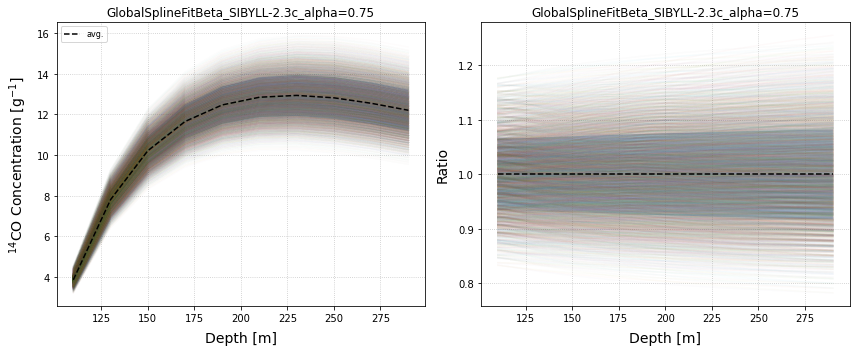

[0.06533259 0.06741589 0.06971007 0.07195389 0.07406814 0.07601751
 0.0778489  0.07953636 0.08112424 0.08251418]
Average relative uncertainty: 7.5%


In [52]:
# Uncertainty over f-factors

N_samp = np.shape(C_pred_0)[-1]
CO_cut = CO_all_f[:,1:,-1].reshape((-1,np.shape(CO_all_f)[-1]))
#names_cut = m_names[:,2,-1]
CO_cut_avg = np.average(CO_cut, axis=0)
CO_cut_cov = np.cov(CO_cut.T)

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)

ax0.fill_between(Prop.z_samp, CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)), CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)), alpha=0.3)
ax1.fill_between(Prop.z_samp, (CO_cut_avg-np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, (CO_cut_avg+np.sqrt(np.diag(CO_cut_cov)))/CO_cut_avg, alpha=0.3)
for i,c in enumerate(CO_cut):
    ax0.plot(Prop.z_samp, c, alpha=0.01)
    ax1.plot(Prop.z_samp, c/CO_cut_avg, alpha=0.02)
ax0.plot(Prop.z_samp, CO_cut_avg, ls='--', c='k', label='avg.')
ax1.plot(Prop.z_samp, CO_cut_avg/CO_cut_avg, ls='--', c='k', label='avg.')

ax0.legend(fontsize=8, ncols=2)
ax0.set(
    xlabel='Depth [m]',
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=m_names[0,2,-1]
)

ax1.set(
    xlabel='Depth [m]',
    ylabel='Ratio',
    title=m_names[0,2,-1]
)
plt.show()

print(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)
print('Average relative uncertainty: {:.1f}%'.format(np.mean(np.sqrt(np.diag(CO_cut_cov))/CO_cut_avg)*100))

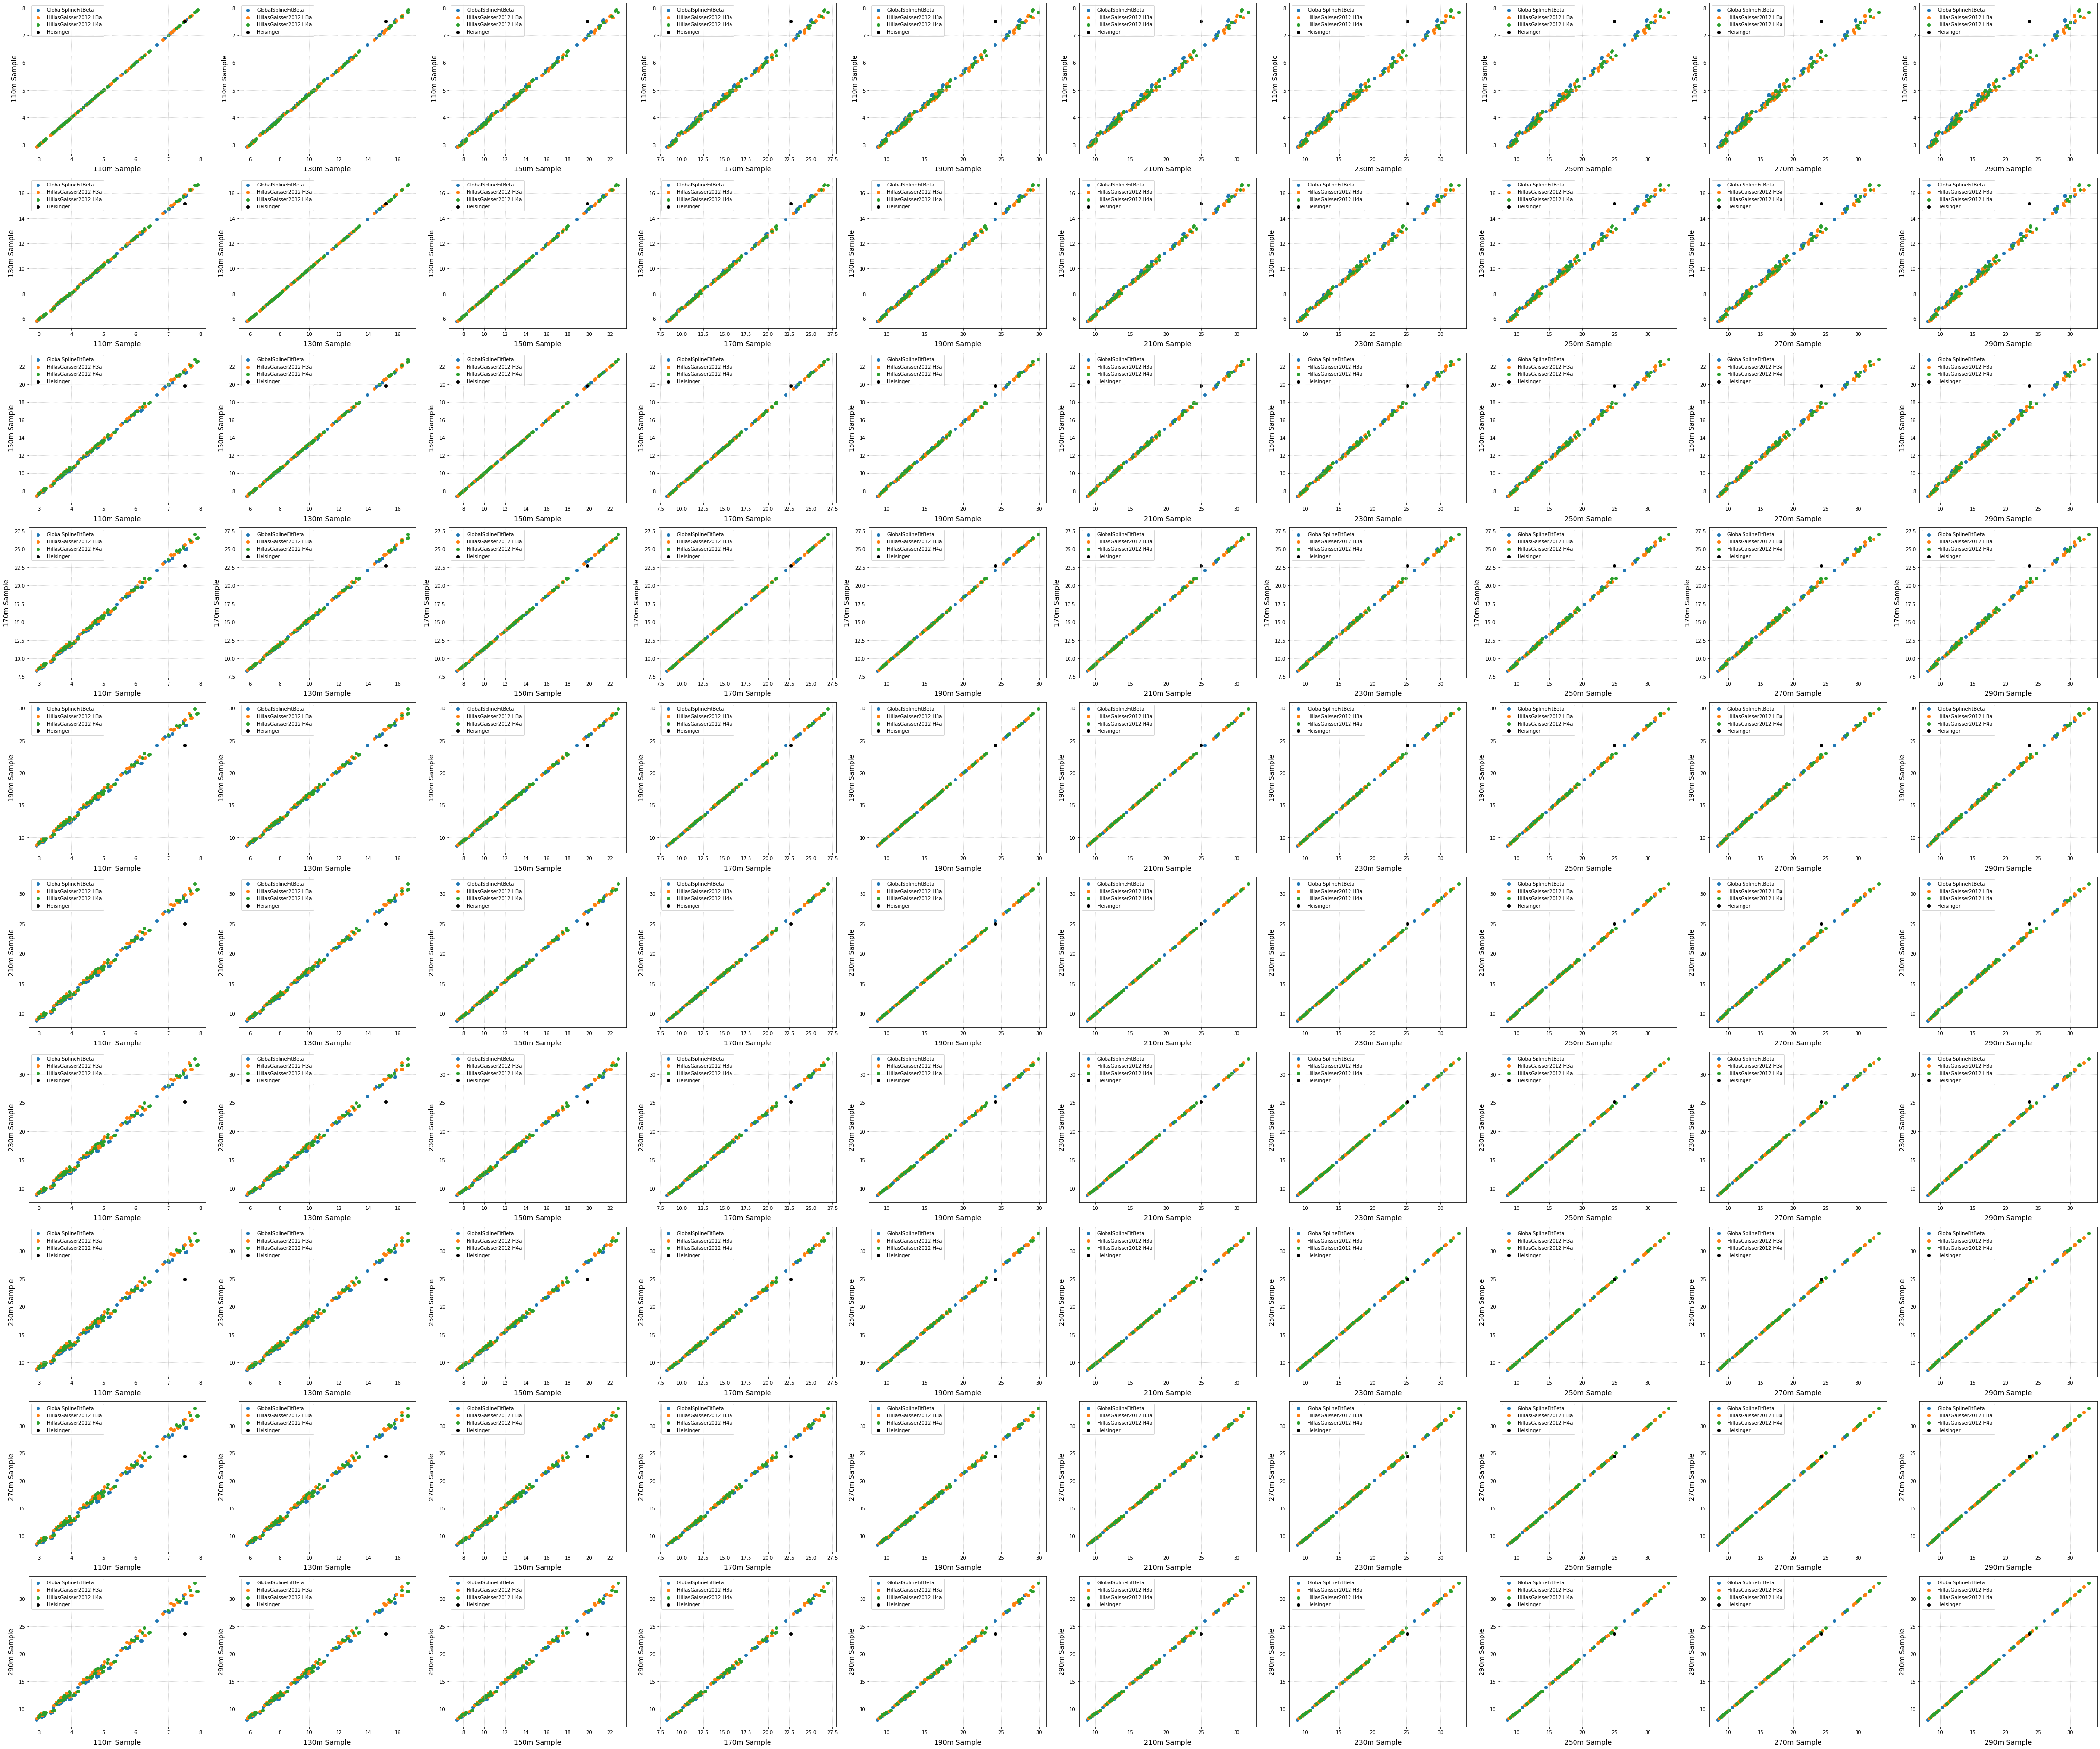

In [17]:
# Correlations by Primary CR model

N_samp = np.shape(C_pred_0)[-1]
fig, ax = plt.subplots(N_samp, N_samp, figsize=(60,50), tight_layout=True)

for i in range(N_samp):
    for j in range(N_samp):
        for k,c in enumerate(CO_all[:,1:]):
            ax[j,i].scatter(c[:,:,i],c[:,:,j], label=m_names[k,0,0].split('_')[0])
        ax[j,i].scatter(f_avg@C_pred_0[-1,:,i],f_avg@C_pred_0[-1,:,j], c='k', label=model_names[-1])
        ax[j,i].legend()
        ax[j,i].set(
            xlabel='{:.0f}m Sample'.format(Prop.z_samp[i]),
            ylabel='{:.0f}m Sample'.format(Prop.z_samp[j]),
        )
plt.show()

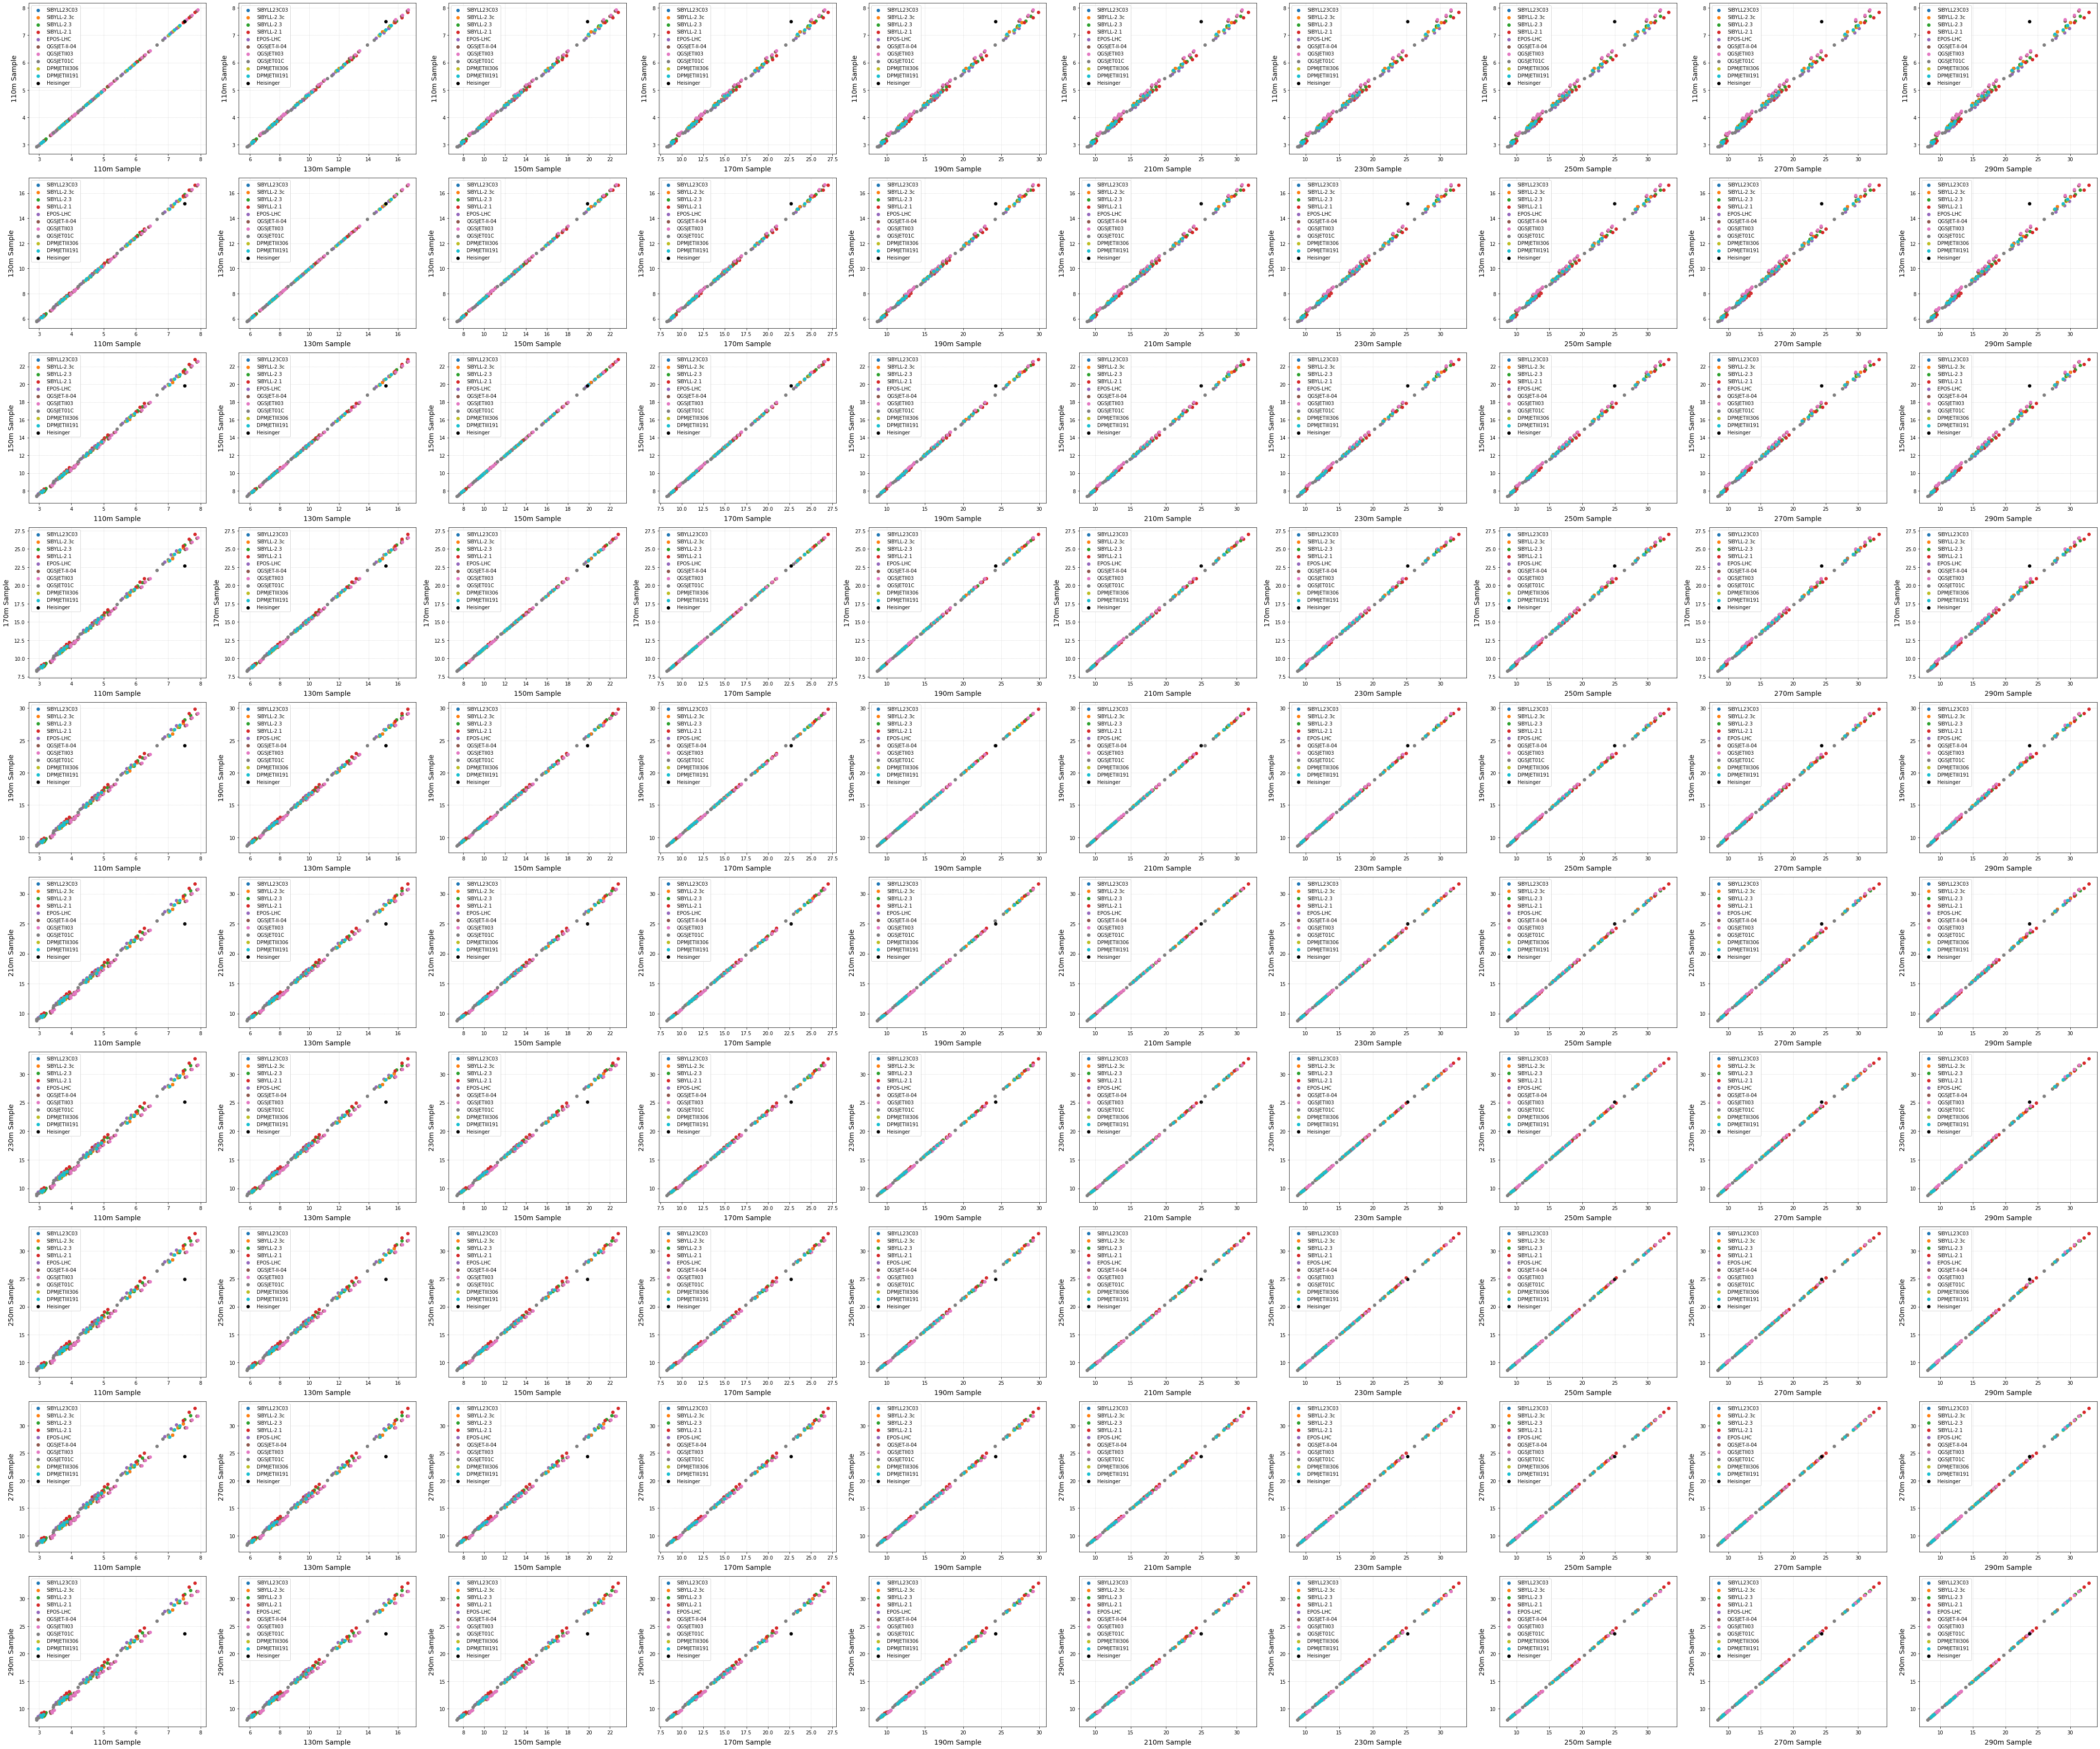

In [18]:
# Correlations by Propagation model

N_samp = np.shape(C_pred_0)[-1]
fig, ax = plt.subplots(N_samp, N_samp, figsize=(60,50), tight_layout=True)

for i in range(N_samp):
    for j in range(N_samp):
        for k,c in enumerate(CO_all[:,1:].swapaxes(0,1)):
            ax[j,i].scatter(c[:,:,i],c[:,:,j], label=m_names[0,k+1,0].split('_')[1])
        ax[j,i].scatter(f_avg@C_pred_0[-1,:,i],f_avg@C_pred_0[-1,:,j], c='k', label=model_names[-1])
        ax[j,i].legend()
        ax[j,i].set(
            xlabel='{:.0f}m Sample'.format(Prop.z_samp[i]),
            ylabel='{:.0f}m Sample'.format(Prop.z_samp[j]),
        )
plt.show()

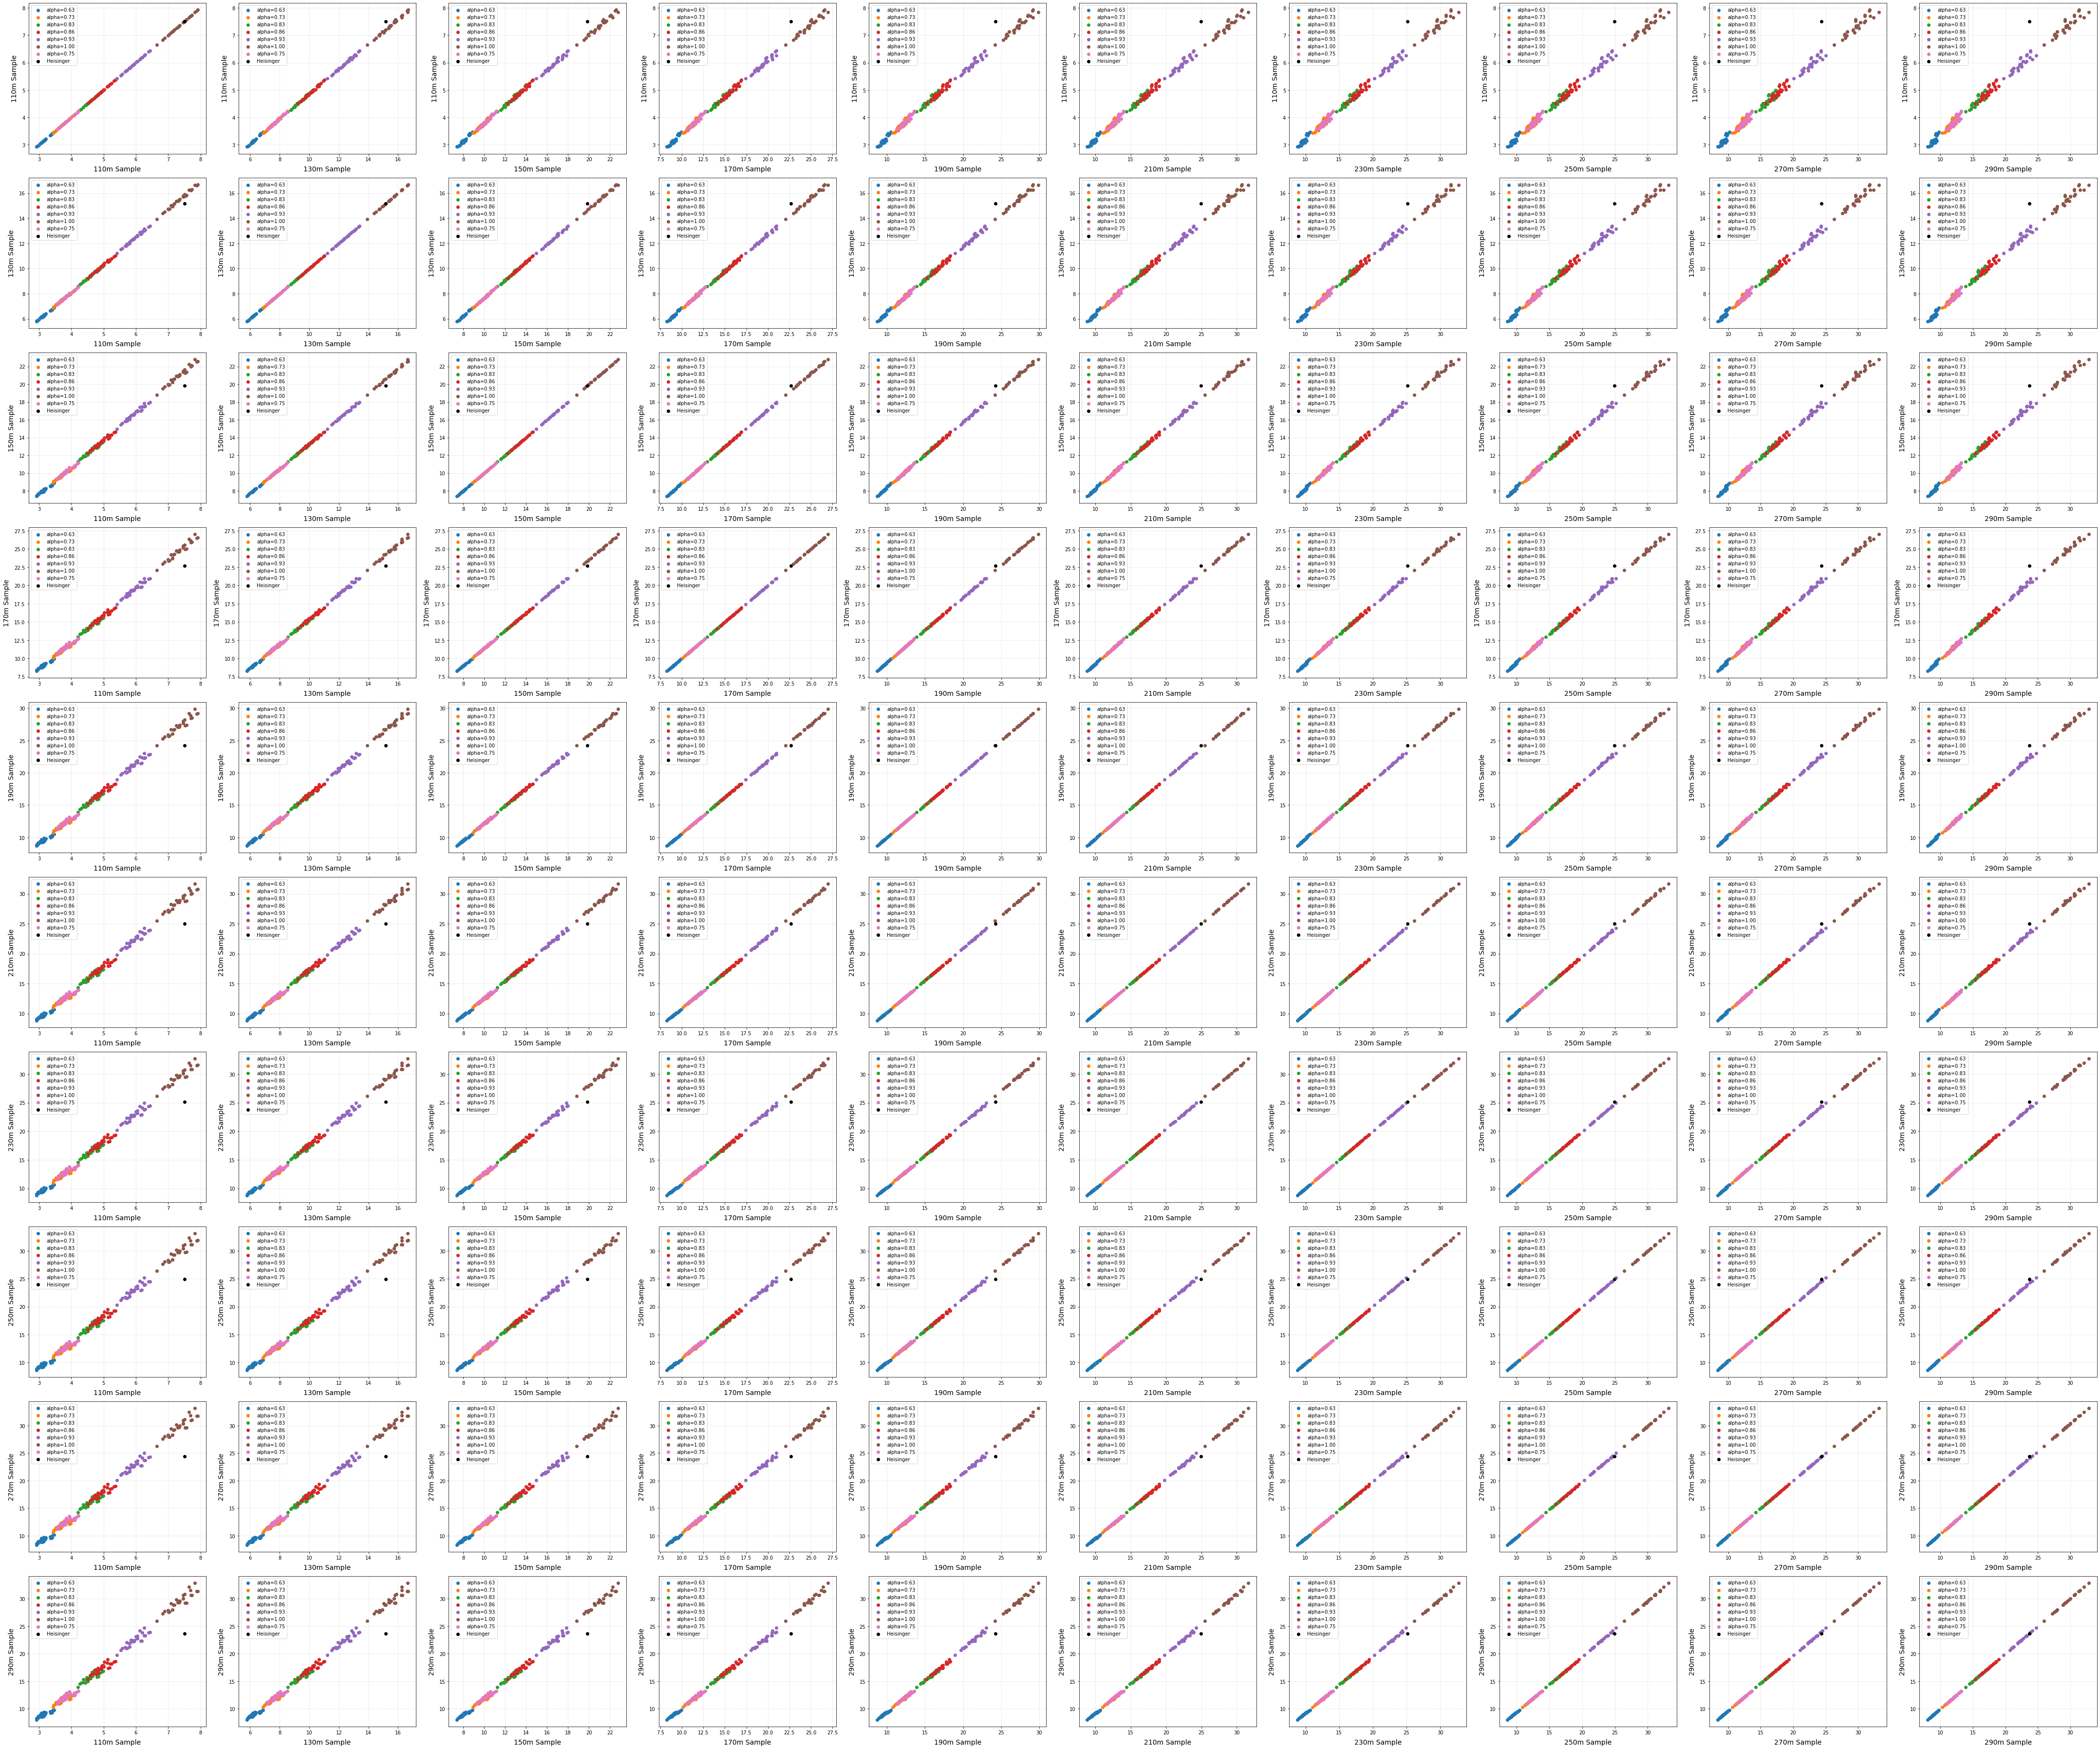

In [19]:
# Correlations by 14C Production model

N_samp = np.shape(C_pred_0)[-1]
fig, ax = plt.subplots(N_samp, N_samp, figsize=(60,50), tight_layout=True)

for i in range(N_samp):
    for j in range(N_samp):
        for k,c in enumerate(CO_all[:,1:].swapaxes(0,2)):
            ax[j,i].scatter(c[:,:,i],c[:,:,j], label=m_names[0,0,k].split('_')[2])
        ax[j,i].scatter(f_avg@C_pred_0[-1,:,i],f_avg@C_pred_0[-1,:,j], c='k', label=model_names[-1])
        ax[j,i].legend()
        ax[j,i].set(
            xlabel='{:.0f}m Sample'.format(Prop.z_samp[i]),
            ylabel='{:.0f}m Sample'.format(Prop.z_samp[j]),
        )
plt.show()